<a href="https://colab.research.google.com/github/scalabrinig/cdProjetoAplicadoIV/blob/master/projeto/cd_projeto_aplicado_IV_entrega_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  <img src="https://raw.githubusercontent.com/scalabrinig/cdProjetoAplicadoIV/d093146488f56dfcf0ef286bcee8efe0e71b9c76/figuras/mackenzie_logo.jpg" width="25%" align="right"/>

# **PROJETO APLICADO IV - Ciência de Dados EaD - 2025/01**


# **Entrega 3**

---

# **Título do Projeto**
---

In [1]:
#@title **Identificação do Grupo e Opção do Projeto**

#@markdown Integrantes do Grupo, nome completo em ordem alfabética (*informe: \<nome\>, \<matrícula\>*)
Aluno1 = 'Aluno 1, 123456789' #@param {type:"string"}
Aluno2 = 'Aluno 2, 123456789' #@param {type:"string"}
Aluno3 = 'Aluno 3, 123456789' #@param {type:"string"}
Aluno4 = 'Aluno 4, 123456789' #@param {type:"string"}
Aluno5 = 'Aluno 5, 123456789' #@param {type:"string"}


# **Introdução**

Juntar os tópicos de contexto, motivação, objetivo geral, objetivos específicos (incluir a bases de dados que será explorada) e justificativa em um único tópico.

# **Referencial Teórico**

(1 página) Defir resumidamente os principais conceitos envolvidos na sua solução. Discutir os trabalhos correlacionados. Apresentar alternativas de solução que foram empregadas no mesmo problema ou problemas semelhantes, e suas vantagens e limitações. Indicar referências ao longo do texto (padrão ABNT).



# **Diagrama de Solução**

Apresente e discuta o diagrama da solução proposta. Utilize o pipeline proposto inicialmente como base.

# **EDA e Pré-processamento dos dados**

Exploração e análise dos dados. Discussão e análise dos dados empregados (qualidade, limitações, simplicações ou recortes adotados etc.). Tarefas de preparação dos dados (transformações, compactação e encodes, junções de dados etc.).

In [ ]:
import pandas as pd

df1 = pd.read_parquet("../dados/SP_poluicao_part1.parquet")
df2 = pd.read_parquet("../dados/SP_poluicao_part2.parquet")

poluicao_sp = pd.concat([df1, df2], ignore_index=True)
poluicao_sp = poluicao_sp.sort_values(by='Data', ascending=True)
poluicao_sp = poluicao_sp.drop(['Unnamed: 0'], axis=1)

poluicao_sp.head()

,Unnamed: 0,ID,Data,Hora,Estacao,Codigo,Poluente,Valor,Unidade,Tipo
9938956,56492,56492,2015-01-01,01:00,Bauru,SP06,MP10,47.0,ug/m3,automatica
10296422,413958,413958,2015-01-01,12:00,Diadema,SP21,O3,86.0,ug/m3,automatica
10296423,413959,413959,2015-01-01,13:00,Diadema,SP21,O3,83.0,ug/m3,automatica
10296424,413960,413960,2015-01-01,14:00,Diadema,SP21,O3,85.0,ug/m3,automatica
10296425,413961,413961,2015-01-01,15:00,Diadema,SP21,O3,83.0,ug/m3,automatica


In [3]:
poluicao_sp['Data'].agg(['min', 'max'])

min    2015-01-01
max    2021-12-31
Name: Data, dtype: object

In [11]:
poluicao_sp[['Estacao', 'Codigo']].drop_duplicates().sort_values(by='Estacao', ascending=True)

,Estacao,Codigo
4791432,Americana,SP137
9889136,Americana - Vila Santa Maria,SP01
9930850,Araraquara,SP03
9905795,Araçatuba,SP02
7962466,Barretos - América,SP05
...,...,...
7916863,Taboão da Serra,SP75
7963994,Tatuapé,SP76
7938379,Tatuí,SP77
7953203,Taubaté,SP78


In [13]:
poluentes = poluicao_sp['Poluente'].drop_duplicates().sort_values(ascending=True)

print(f"Há {len(poluentes)} poluentes na base de dados.")
poluentes

Há 9 poluentes na base de dados.


10545756       CO
7962954       FMC
9938956      MP10
10823329    MP2.5
3927803        NO
10143202      NO2
10296422       O3
7963284       PTS
7845211       SO2
Name: Poluente, dtype: object

# **Modelo base**

Aplicação de, pelo menos, um primeiro modelo (modelo de aprendizado de máquina ou modelo estatístico) que deve ser refinado até a entrega final do projeto. Apresente o método aplicado e a análise dos resultados obtidos.

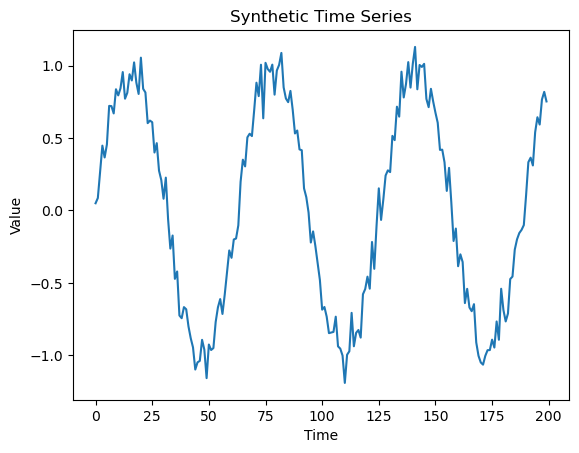

Test MSE: 0.0152


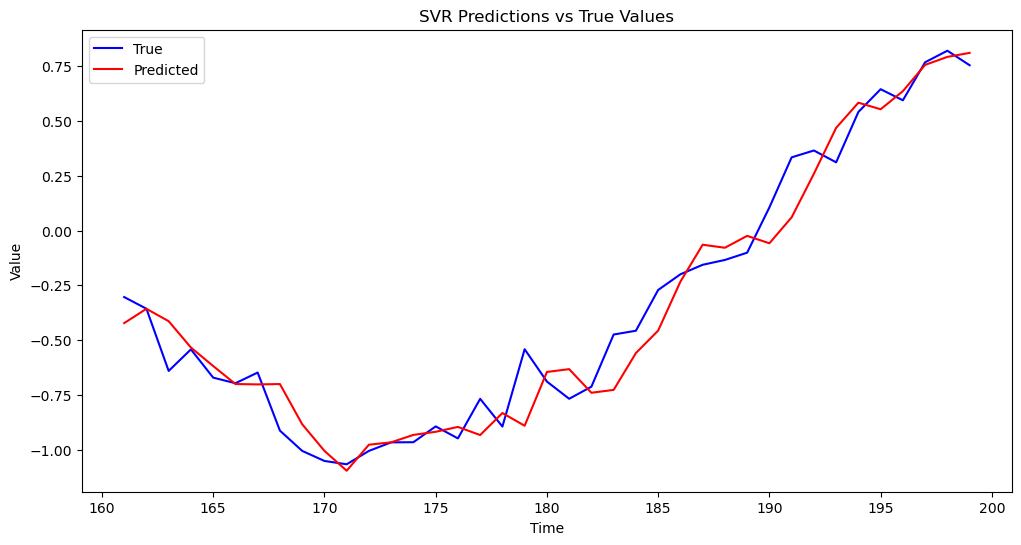

In [15]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

def series_to_supervised(data, n_lags):
    """
    Transform a 1D array into supervised learning format with lagged features.
    """
    df = pd.DataFrame({'y': data})
    for lag in range(1, n_lags + 1):
        df[f'y(t-{lag})'] = df['y'].shift(lag)
    return df.dropna()

# 1. Generate synthetic time series
np.random.seed(42)
t = np.arange(0, 200)
series = np.sin(0.1 * t) + np.random.normal(0, 0.1, size=len(t))

# 2. Plot synthetic data
plt.plot(t, series)
plt.title('Synthetic Time Series')
plt.xlabel('Time')
plt.ylabel('Value')
plt.show()

# 3. Prepare supervised data
n_lags = 5
df = series_to_supervised(series, n_lags)
X = df.drop('y', axis=1).values
y = df['y'].values

# 4. Train-test split
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# 5. Scale features and target
scaler_X = StandardScaler().fit(X_train)
scaler_y = StandardScaler().fit(y_train.reshape(-1, 1))

X_train_s = scaler_X.transform(X_train)
X_test_s = scaler_X.transform(X_test)
y_train_s = scaler_y.transform(y_train.reshape(-1, 1)).ravel()

# 6. Train SVR
model = SVR(kernel='rbf', C=10, epsilon=0.01)
model.fit(X_train_s, y_train_s)

# 7. Predict and compute MSE
y_pred_s = model.predict(X_test_s)
y_pred = scaler_y.inverse_transform(y_pred_s.reshape(-1, 1)).ravel()
mse = mean_squared_error(y_test, y_pred)
print(f'Test MSE: {mse:.4f}')

# 8. Plot predictions and the original series
plt.figure(figsize=(12, 6))
plt.plot(t[split_idx+5:], y_test, label='True', color='blue')
plt.plot(t[split_idx+5:], y_pred, label='Predicted', color='red')
plt.title('SVR Predictions vs True Values')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()

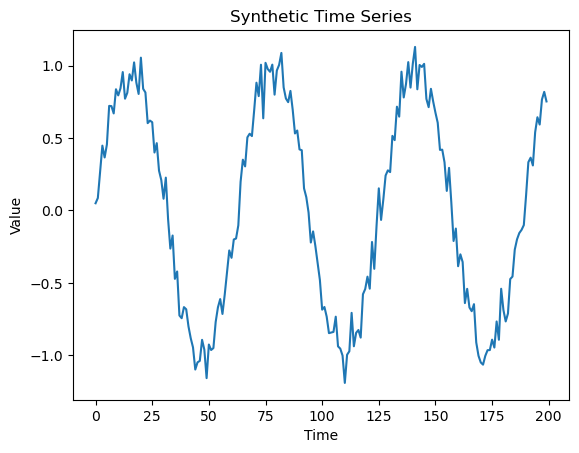

Test MSE: 0.3822


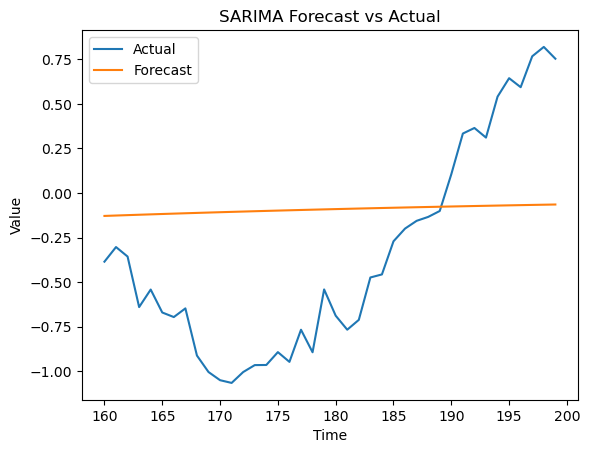

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 1. Generate synthetic time series
np.random.seed(42)
t = np.arange(0, 200)
series = np.sin(0.1 * t) + np.random.normal(0, 0.1, size=len(t))

# 2. Plot synthetic data
plt.plot(t, series)
plt.title('Synthetic Time Series')
plt.xlabel('Time')
plt.ylabel('Value')
plt.show()

# 3. Split into train/test (80% train)
split_idx = int(len(series) * 0.8)
train, test = series[:split_idx], series[split_idx:]

# 4. Fit SARIMA model: non-seasonal example (p=1, d=0, q=1)
model = SARIMAX(train,
                order=(1, 0, 1),
                seasonal_order=(0, 0, 0, 0),
                enforce_stationarity=False,
                enforce_invertibility=False)
result = model.fit(disp=False)

# 5. Forecast on test set
forecast = result.forecast(steps=len(test))

# 6. Compute MSE
mse = mean_squared_error(test, forecast)
print(f'Test MSE: {mse:.4f}')

# 7. Plot forecast vs actual
plt.plot(np.arange(split_idx, len(series)), test, label='Actual')
plt.plot(np.arange(split_idx, len(series)), forecast, label='Forecast')
plt.title('SARIMA Forecast vs Actual')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()


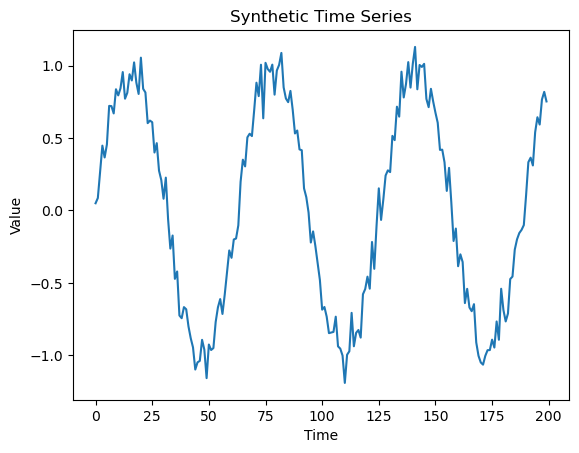

Test MSE: 0.0174


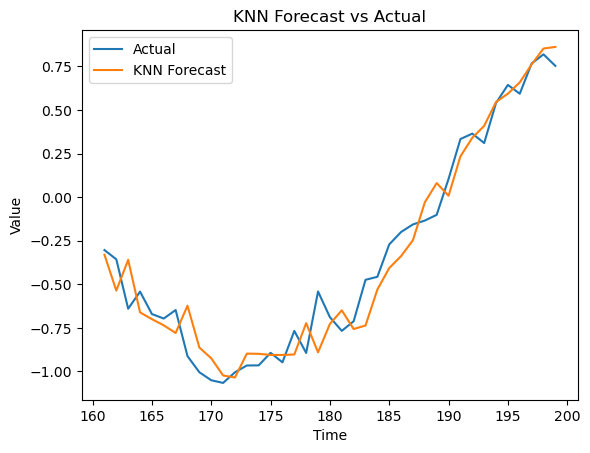

In [16]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

def series_to_supervised(data, n_lags):
    df = pd.DataFrame({'y': data})
    for lag in range(1, n_lags + 1):
        df[f'y(t-{lag})'] = df['y'].shift(lag)
    return df.dropna()

# Generate data
np.random.seed(42)
t = np.arange(0, 200)
series = np.sin(0.1 * t) + np.random.normal(0, 0.1, size=len(t))

# Plot series
plt.plot(t, series)
plt.title('Synthetic Time Series')
plt.xlabel('Time')
plt.ylabel('Value')
plt.show()

# Prepare supervised data
n_lags = 5
df = series_to_supervised(series, n_lags)
X = df.drop('y', axis=1).values
y = df['y'].values
time_idx = df.index.values

# Split
split_point = int(len(X) * 0.8)
X_train, X_test = X[:split_point], X[split_point:]
y_train, y_test = y[:split_point], y[split_point:]
t_test = time_idx[split_point:]

# Scale features
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

# Train KNN
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_s, y_train)

# Predict & MSE
y_pred = knn.predict(X_test_s)
mse = mean_squared_error(y_test, y_pred)
print(f'Test MSE: {mse:.4f}')

# Plot actual vs forecast
plt.plot(t_test, y_test, label='Actual')
plt.plot(t_test, y_pred, label='KNN Forecast')
plt.title('KNN Forecast vs Actual')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()


# **Cronograma**

Atualizar o cronograma, se necessário, das atividades.

# **Referências**

Complementar a entrega anterior.




In [2]:
#@title **Avaliação**
EDA_e_preprocessamento = 10 #@param {type:"slider", min:0, max:10, step:1}

Modelo_base = 10 #@param {type:"slider", min:0, max:10, step:1}

Revisao = 10 #@param {type:"slider", min:0, max:10, step:1}

Apresentacao_geral = 10 #@param {type:"slider", min:0, max:10, step:1}








In [3]:
#@title **Nota Final**
nota = 0.4*EDA_e_preprocessamento + 0.2*Modelo_base + 0.2*Revisao + 0.2*Apresentacao_geral

print(f'Nota final do trabalho {nota :.1f}')

import numpy as np
import pandas as pd

alunos = pd.DataFrame()

lista_nome = []

for i in range(1,6):
  exec("if Aluno" + str(i) + " !='None':  lista = Aluno" + str(i) + ".split(','); lista_nome.append(lista[0]);")

alunos['nome'] = lista_nome
alunos['nota'] = np.round(nota,1)
print()
display(alunos)

Nota final do trabalho 10.0



,nome,nota
0,Aluno 1,10.0
1,Aluno 2,10.0
2,Aluno 3,10.0
3,Aluno 4,10.0
4,Aluno 5,10.0
